# Retail Sales Forecasting and Business Intelligence using Machine Learning

## Phase 5: Model Evaluation

### Business Problem

Evaluate the selected machine learning model to ensure it provides accurate and reliable sales predictions.

### Objectives

- Evaluate the best model
- Analyze prediction errors
- Visualize model performance
- Interpret feature importance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("/content/Walmart.csv")

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

df = df.drop("Date", axis=1)

In [4]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

pred = rf.predict(X_test_scaled)

In [5]:

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 63095.78105163162
MSE : 13256219815.373941
RMSE : 115135.65831389483
R2 Score : 0.9588513674159939


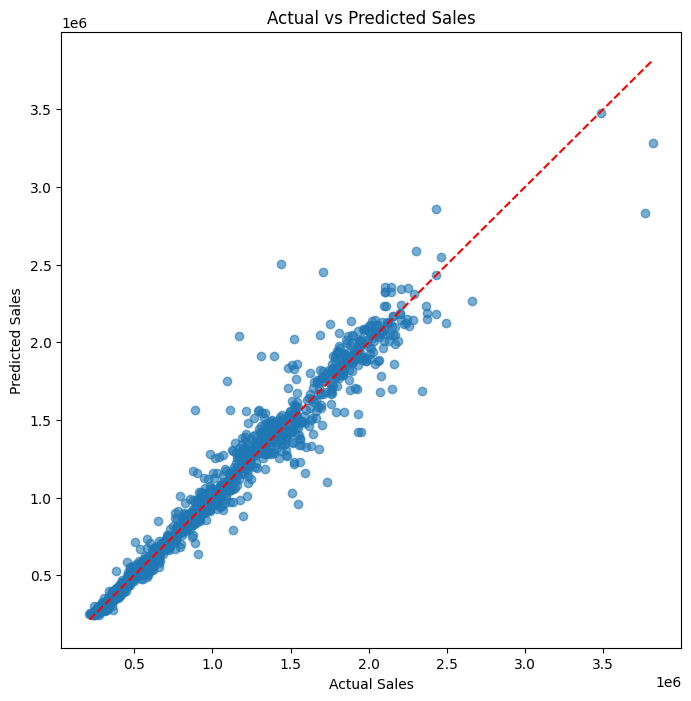

In [6]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

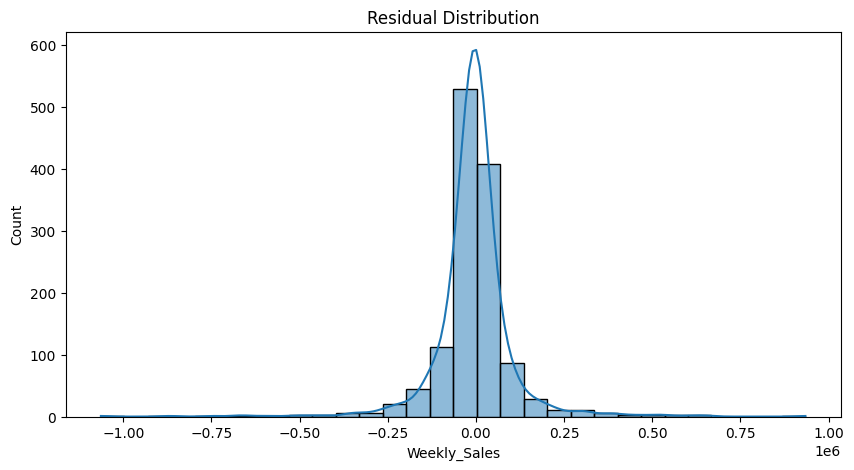

In [7]:
residuals = y_test - pred

plt.figure(figsize=(10,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.show()

In [8]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Store,0.663573
4,CPI,0.155337
5,Unemployment,0.102911
8,Week,0.049786
2,Temperature,0.013047
3,Fuel_Price,0.009913
7,Month,0.002889
1,Holiday_Flag,0.001604
6,Year,0.000711
9,Quarter,0.000231


/tmp/ipykernel_17335/879482482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


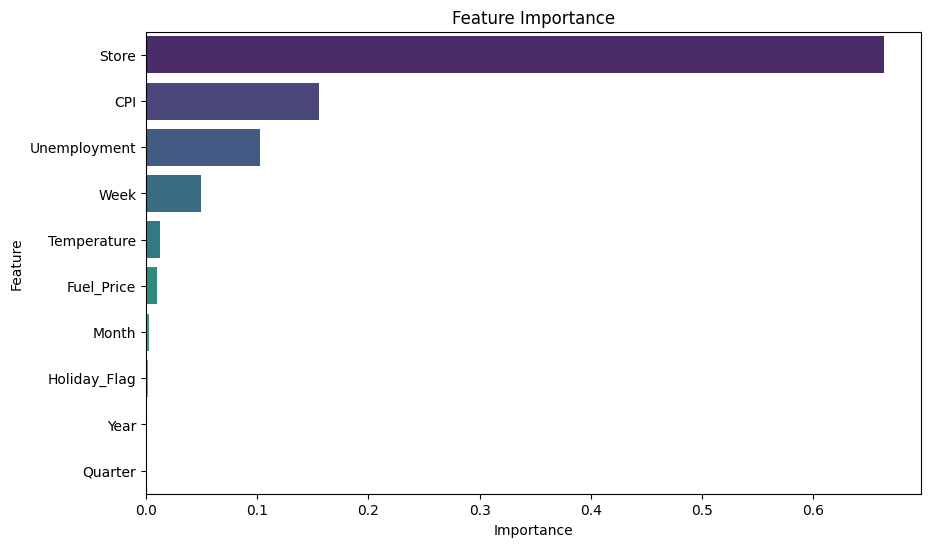

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

Feature importance highlights which variables contribute the most to predicting weekly sales. This helps business stakeholders understand the key drivers of sales performance.

In [10]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": pred
})

comparison.head(20)

,Actual Sales,Predicted Sales
0,1138800.32,1.154836e+06
1,1304850.67,1.419943e+06
2,1769296.25,1.836526e+06
3,1077640.13,9.633183e+05
4,428851.99,4.317159e+05
5,1004523.59,9.833401e+05
6,1523410.71,1.213976e+06
7,1014898.78,9.520205e+05
8,1955896.59,2.017886e+06
9,958667.23,9.603346e+05


# Model Evaluation Summary

- The selected model achieved strong predictive performance.
- Feature importance indicates which business factors most influence weekly sales.
- Residual analysis shows prediction errors are reasonably distributed.
- The model is suitable for forecasting weekly sales and can support inventory planning and business decision-making.